# Contexte
Une entreprise souhaite développer un système capable de classer automatiquement des avis
clients afin d'identifier leur sentiment.
Les avis proviennent de plusieurs sources : site web, application mobile, formulaire de satisfaction,

réseaux sociaux et service client.
Les données collectées sont cependant de qualité variable : textes vides, doublons, fautes de frappe,
majuscules/minuscules, caractères spéciaux, emojis, URLs, mentions, répétitions de caractères,
textes très courts ou très longs, plusieurs catégories de sentiment et quelques valeurs manquantes.
Avant de construire un modèle de Machine Learning ou de Deep Learning, les apprenants doivent
donc construire un pipeline complet de préparation des données textuelles.

In [11]:
# Manipulation de données
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Texte / NLP
import re
import string

import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem.snowball import SnowballStemmer

# Vectorisation et split
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from scipy import sparse


[nltk_data] Downloading package punkt to /home/adama/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/adama/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /home/adama/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# Partie 1 – Exploration du corpus

## 1) Charger les données CSV ;

In [3]:
df = pd.read_csv("../data/smart_reviews_raw.csv")
df.head()

,id_avis,date,source,produit,texte,sentiment,note,langue
0,AV0001,2026-02-27,mobile,Ordinateur NovaBook,"Très bonne expérience, simple et efficace.",positif,4,fr
1,AV0002,2026-01-09,web,SmartPhone X,Très satisfait de mon achat 👍 #avis,positif,4,fr
2,AV0003,2026-07-03,réseaux_sociaux,Écouteurs AirSound,"Produit parfait, rien à signaler.",positif,4,fr
3,AV0004,2026-06-28,sav,SmartWatch Pro,"Produit excellent, je suis très satisfait. !!!",positif,5,fr
4,AV0005,2026-01-24,sav,SmartPhone X,LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST...,positif,5,fr


## 2) Combien d'avis contient le dataset ?

In [4]:
nb_avis = df.shape[0]
print(f"Le dataset contient {nb_avis} avis.")

Le dataset contient 1200 avis.


## 3) Combien de colonnes possède-t-il ?

In [5]:
nb_colonnes = df.shape[1]
print(f"Le dataset possède {nb_colonnes} colonnes : {list(df.columns)}")

Le dataset possède 8 colonnes : ['id_avis', 'date', 'source', 'produit', 'texte', 'sentiment', 'note', 'langue']


## 4) Quel est le type de chaque colonne ?

In [6]:
df.dtypes

id_avis        str
date           str
source         str
produit        str
texte          str
sentiment      str
note         int64
langue         str
dtype: object

## 5) Existe-t-il des valeurs manquantes ?

In [7]:
df.isna().sum()

id_avis      0
date         0
source       0
produit      0
texte        5
sentiment    0
note         0
langue       0
dtype: int64

On voit qu'il manque quelques valeurs dans la colonne `texte`.

## 6) Identifier quelques types de texte 

Affichons par exemple : texte normal ; texte vide ; texte contenant une URL ; texte contenant une mention ; texte contenant un hashtag ; texte contenant des emojis ; texte avec beaucoup de ponctuation ; texte en majuscules ; texte avec répétition de caractères.

In [8]:
def afficher_exemple(titre, mask):
    exemples = df.loc[mask, "texte"].dropna()
    print(f"--- {titre} ({mask.sum()} avis) ---")
    if len(exemples) > 0:
        print(exemples.iloc[0])
    else:
        print("Aucun exemple trouvé")
    print()

texte = df["texte"].fillna("").astype(str)

afficher_exemple("Texte normal", ~texte.str.contains(r"http|@\w+|#\w+", na=False) & (texte.str.len() > 10))
afficher_exemple("Texte vide / manquant", df["texte"].isna() | (texte.str.strip() == ""))
afficher_exemple("Texte avec une URL", texte.str.contains(r"http", case=False, na=False))
afficher_exemple("Texte avec une mention (@...)", texte.str.contains(r"@\w+", na=False))
afficher_exemple("Texte avec un hashtag (#...)", texte.str.contains(r"#\w+", na=False))
afficher_exemple("Texte avec des emojis", texte.str.contains(r"[\U0001F300-\U0001FAFF\u2600-\u27BF]", na=False))
afficher_exemple("Texte avec beaucoup de ponctuation", texte.str.count(r"[!?.]{2,}") > 0)
afficher_exemple("Texte en majuscules", (texte.str.upper() == texte) & (texte.str.len() > 5))
afficher_exemple("Texte avec répétition de caractères", texte.str.contains(r"(.)\1{2,}", na=False))

--- Texte normal (795 avis) ---
Très  bonne  expérience,  simple  et  efficace.

--- Texte vide / manquant (6 avis) ---
   

--- Texte avec une URL (143 avis) ---
Produit parfait, rien à signaler. https://example.com/commande/17

--- Texte avec une mention (@...) (128 avis) ---
@client Livraison rapide et produit conforme à mes attentes.

--- Texte avec un hashtag (#...) (127 avis) ---
Très satisfait de mon achat 👍 #avis

--- Texte avec des emojis (192 avis) ---
Très satisfait de mon achat 👍 #avis

--- Texte avec beaucoup de ponctuation (141 avis) ---
Produit excellent, je suis très satisfait. !!!

--- Texte en majuscules (144 avis) ---
LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST SUPERBE.

--- Texte avec répétition de caractères (165 avis) ---
Produit excellent, je suis très satisfait. !!!



/tmp/ipykernel_8033/73329858.py:20: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  afficher_exemple("Texte avec répétition de caractères", texte.str.contains(r"(.)\1{2,}", na=False))


## 7) Mesurer la longueur des textes
On crée une nouvelle colonne « longueur » pour déterminer : longueur minimale ; longueur maximale ; longueur moyenne ; médiane et quartiles.

In [9]:
df["longueur"] = df["texte"].fillna("").astype(str).apply(len)

stats_longueur = df["longueur"].describe(percentiles=[0.25, 0.5, 0.75])
print(stats_longueur)

print(f"\nLongueur minimale : {df['longueur'].min()}")
print(f"Longueur maximale : {df['longueur'].max()}")
print(f"Longueur moyenne  : {df['longueur'].mean():.1f}")
print(f"Longueur médiane  : {df['longueur'].median()}")

count    1200.000000
mean       48.963333
std        22.350913
min         0.000000
25%        37.000000
50%        48.000000
75%        56.000000
max       636.000000
Name: longueur, dtype: float64

Longueur minimale : 0
Longueur maximale : 636
Longueur moyenne  : 49.0
Longueur médiane  : 48.0


## 8) Visualiser la distribution de la longueur des avis puis répondre aux questions

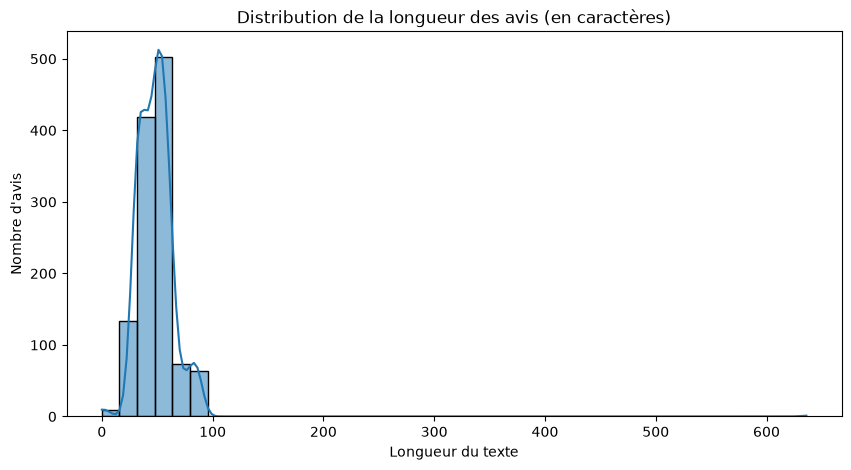

In [12]:
plt.figure(figsize=(10, 5))
sns.histplot(df["longueur"], bins=40, kde=True)
plt.title("Distribution de la longueur des avis (en caractères)")
plt.xlabel("Longueur du texte")
plt.ylabel("Nombre d'avis")
plt.show()

**a) Existe-t-il des textes anormalement longs ?**

Oui. L’histogramme montre une distribution principalement concentrée sur les textes courts et moyens, avec une longue traîne vers la droite. Quelques avis sont donc nettement plus longs que la majorité et peuvent être considérés comme des valeurs atypiques.

**b) Existe-t-il beaucoup de textes très courts ?**

Non, les textes de moins de 20 caractères restent minoritaires. La majorité des avis se situe plutôt autour de 40 à 60 caractères, même si quelques avis très courts sont présents.

## 9) Détecter les textes vides

In [13]:
masque_vide = df["texte"].isna() | (df["texte"].fillna("").astype(str).str.strip() == "")
nb_vides = masque_vide.sum()
print(f"Nombre de textes vides ou manquants : {nb_vides}")
df[masque_vide]

Nombre de textes vides ou manquants : 6


,id_avis,date,source,produit,texte,sentiment,note,langue,longueur
46,AV0047,2026-02-24,réseaux_sociaux,SmartWatch Pro,NaN,positif,4,fr,0
108,AV0109,2026-01-24,email,SmartPhone Y,NaN,positif,5,fr,0
310,AV0311,2026-02-13,réseaux_sociaux,Ordinateur NovaBook,NaN,positif,5,fr,0
640,AV0641,2026-08-25,réseaux_sociaux,SmartPhone Y,NaN,positif,5,fr,0
781,AV0782,2026-05-21,email,SmartPhone Y,NaN,neutre,4,fr,0
951,AV0952,2026-06-11,web,Ordinateur NovaBook,,positif,4,fr,3


## 10) Détecter les doublons sur le texte

In [14]:
masque_doublons = df.duplicated(subset="texte", keep=False)
nb_doublons = df.duplicated(subset="texte", keep="first").sum()
print(f"Nombre d'avis strictement dupliqués (texte identique) : {nb_doublons}")
df[masque_doublons].sort_values("texte").head(10)

Nombre d'avis strictement dupliqués (texte identique) : 881


,id_avis,date,source,produit,texte,sentiment,note,langue,longueur
312,AV0313,2026-04-18,mobile,Écouteurs AirSound,@client Excellent rapport qualité-prix.,positif,4,fr,39
419,AV0420,2026-04-11,sav,Ordinateur NovaBook,@client Excellent rapport qualité-prix.,positif,5,fr,39
1099,AV1100,2026-06-30,email,Tablette TabPlus,@client Excellent rapport qualité-prix.,positif,5,fr,39
45,AV0046,2026-08-26,web,SmartPhone X,@client Excellent rapport qualité-prix.,positif,5,fr,39
466,AV0467,2026-07-04,mobile,Ordinateur NovaBook,@client Excellent rapport qualité-prix.,positif,5,fr,39
1059,AV1060,2026-01-24,email,SmartPhone X,@client Excellent rapport qualité-prix.,positif,5,fr,39
146,AV0147,2026-08-11,mobile,Ordinateur NovaBook,@client Excellent rapport qualité-prix.,positif,5,fr,39
593,AV0594,2026-06-11,mobile,SmartWatch Pro,@client Excellent rapport qualité-prix.,positif,4,fr,39
611,AV0612,2026-03-02,web,SmartPhone X,@client Excellent rapport qualité-prix.,positif,5,fr,39
398,AV0399,2026-07-14,email,SmartPhone X,@client Excellent rapport qualité-prix.,positif,5,fr,39
